#Mục tiêu của bài toán

Xem xét thị trường bán game của các quốc gia để từ đó biết được thể loại game được ưa thích ở từng nơi và có sự phân bố phù hợp cho việc phát hành ở ngắn hạn lẫn phát triển thể loại game được ưa chuộng ở dài hạn. Ngoài ra còn xem xét đến việc nhà phát hành nào được ưa chuộng để từ đó hướng về việc tham khảo lối làm game của những game, nhà phát hành được ưa chuộng nhằm đáp ứng được thị hiếu của người dùng và đẩy mạnh doanh thu.

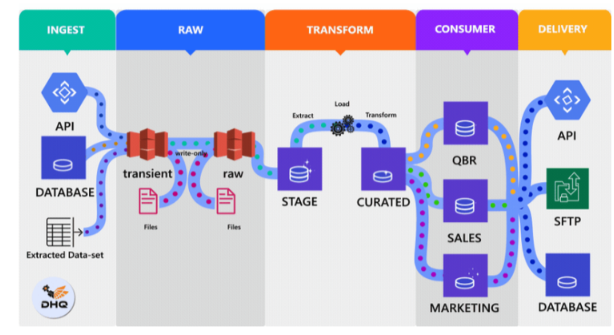

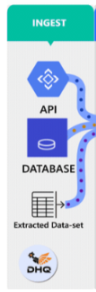

##Giai đoạn Ingest – Thu thập dữ liệu

1. Mục tiêu
Giai đoạn Ingest nhằm thu thập dữ liệu từ các nguồn bên ngoài và đưa vào hệ thống lưu trữ nội bộ để phục vụ cho quá trình xử lý và phân tích. Trong bài toán phân tích dữ liệu trò chơi điện tử, dữ liệu được thu thập từ bộ dữ liệu "Video Game Sales Data" trên Kaggle.

2. Nguồn dữ liệu
Tên bộ dữ liệu: Video Game Sales Data

Nguồn: Kaggle (https://www.kaggle.com/datasets/gregorut/videogamesales)

Định dạng dữ liệu: CSV

Các thông tin chính trong dữ liệu:

Tên trò chơi (Name)

Nền tảng phát hành (Platform)

Năm phát hành (Year)

Thể loại (Genre)

Nhà phát hành (Publisher)

Doanh số bán hàng tại các khu vực (Bắc Mỹ, Châu Âu, Nhật Bản, Toàn cầu)

3. Phương pháp thu thập dữ liệu

Dữ liệu được tải xuống từ Kaggle dưới dạng tệp CSV và được nhập vào hệ thống lưu trữ sử dụng Python. Quy trình thu thập được thực hiện như sau:

Tải tệp dữ liệu từ Kaggle.

Đọc dữ liệu bằng Pandas để kiểm tra chất lượng và định dạng dữ liệu.

Lưu trữ vào hệ thống cơ sở dữ liệu hoặc lưu dưới dạng file thô để tiếp tục xử lý.

4. Công cụ sử dụng

Python, Pandas: Đọc và kiểm tra dữ liệu từ file CSV.

Google Colab: Môi trường chạy mã nguồn để kiểm tra dữ liệu.



1️⃣ Tải dataset lên Google Colab

In [ ]:
from google.colab import files

uploaded = files.upload()


Saving vgsales.csv to vgsales.csv


#Giới thiệu về nguồn dữ liệu
Bộ dữ liệu này chứa danh sách các trò chơi điện tử có doanh số bán ra lớn hơn 100.000 bản. Nó được tạo ra bằng cách thu thập dữ liệu từ vgchartz.com,từ hơn 16.500 trò chơi.

Các trường bao gồm

Rank - Xếp hạng tổng doanh số

Name - Tên trò chơi

Platform  - Nền tảng phát hành trò chơi (ví dụ: PC, PS4, v.v.)

Year  - Năm phát hành trò chơi

Genre  - Thể loại của trò chơi

Publisher  - Nhà phát hành trò chơi

NA_Sales - Doanh số bán hàng tại Bắc Mỹ (triệu)

EU_Sales - Doanh số bán hàng tại Châu Âu (triệu)

JP_Sales - Doanh số bán hàng tại Nhật Bản (triệu)

Other_Sales - Doanh số bán hàng ở các nơi khác trên thế giới (triệu)

Global_Sales - Tổng doanh số bán hàng trên toàn thế giới.


In [ ]:
import pandas as pd

# Đọc file CSV
df = pd.read_csv("vgsales.csv")

# Xem 5 dòng đầu tiên
print(df.head())

# Kiểm tra thông tin chung
print(df.info())


   Rank                      Name Platform    Year         Genre Publisher  \
0     1                Wii Sports      Wii  2006.0        Sports  Nintendo   
1     2         Super Mario Bros.      NES  1985.0      Platform  Nintendo   
2     3            Mario Kart Wii      Wii  2008.0        Racing  Nintendo   
3     4         Wii Sports Resort      Wii  2009.0        Sports  Nintendo   
4     5  Pokemon Red/Pokemon Blue       GB  1996.0  Role-Playing  Nintendo   

   NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales  
0     41.49     29.02      3.77         8.46         82.74  
1     29.08      3.58      6.81         0.77         40.24  
2     15.85     12.88      3.79         3.31         35.82  
3     15.75     11.01      3.28         2.96         33.00  
4     11.27      8.89     10.22         1.00         31.37  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------  

# RAW

Ở giai đoạn RAW, tôi chọn cách copy file dữ liệu đã tải sang một nơi khác để lưu dưới dạng raw. Còn file đã tải sẽ dùng làm file tránient

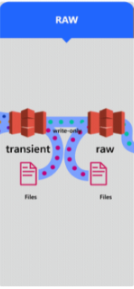

2️⃣ Tiền xử lý dữ liệu

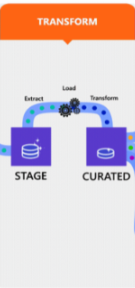

##Xử lý và làm sạch dữ liệu từ bộ dữ liệu "Video Game Sales Data" để đảm bảo tính đầy đủ và chính xác cho các phân tích tiếp theo.

#Kiểm tra dữ liệu còn thiếu

Trong quá trình kiểm tra dữ liệu, tôi đã nhận thấy một số cột trong bộ dữ liệu có các giá trị thiếu (missing values). Để đảm bảo dữ liệu đủ đầy và có thể sử dụng cho các phân tích sau này, tôi đã tiến hành xử lý các giá trị thiếu theo các phương pháp phù hợp.

In [ ]:
# Kiểm tra giá trị null
print(df.isnull().sum())


Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64


#Dùng phương pháp median để điền dữ liệu cột Year

Phương pháp: Đối với cột "Year", dữ liệu thiếu đã được điền bằng giá trị median (trung vị) của cột này.

Lý do: Sử dụng giá trị trung vị để điền vào các dữ liệu thiếu giúp tránh việc ảnh hưởng đến các phân tích sau này, đặc biệt là với những cột có giá trị phân phối không đồng đều. Trung vị giúp giảm thiểu ảnh hưởng của các giá trị ngoại lai (outliers).

Kết quả: Dữ liệu trong cột "Year" đã hoàn chỉnh và sẵn sàng để tiếp tục sử dụng trong các bước phân tích tiếp theo.

In [ ]:
df['Year'] = df['Year'].fillna(df['Year'].median())


#Kiểm tra tỉ lệ thiếu dữ liệu của cột Publisher

Phương pháp: Tôi đã thực hiện kiểm tra tỉ lệ thiếu dữ liệu trong cột "Publisher". Kết quả cho thấy có một tỉ lệ không nhỏ các giá trị thiếu trong cột này.

Lý do: Các giá trị thiếu trong cột "Publisher" có thể là do thiếu thông tin về nhà phát hành cho một số trò chơi trong bộ dữ liệu gốc.

In [ ]:
missing_publisher_ratio = df['Publisher'].isna().sum() / len(df)
print(f"Tỷ lệ thiếu dữ liệu của Publisher: {missing_publisher_ratio:.2%}")


Tỷ lệ thiếu dữ liệu của Publisher: 0.35%


kiểm tra dữ liệu còn thiếu của cột year sau khi xử lí

In [ ]:
print(df.isnull().sum())

Rank             0
Name             0
Platform         0
Year             0
Genre            0
Publisher       58
NA_Sales         0
EU_Sales         0
JP_Sales         0
Other_Sales      0
Global_Sales     0
dtype: int64


#Điền dữ liệu còn thiếu thành "Unknown" vào cột dữ liệu Publisher

Phương pháp: Để xử lý các giá trị thiếu trong cột "Publisher", tôi đã điền các giá trị thiếu bằng từ khóa "Unknown".

Lý do: Việc điền giá trị "Unknown" giúp giữ lại thông tin về sự thiếu vắng nhà phát hành mà không làm mất đi tính toàn vẹn của dữ liệu. Thực tế, "Unknown" là một giá trị hợp lý khi không có thông tin về nhà phát hành.

In [ ]:
df['Publisher'].fillna("Unknown", inplace=True)


<ipython-input-9-0672069f871b>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Publisher'].fillna("Unknown", inplace=True)


Kiểm tra lại một lần cuối

In [ ]:
print(df.isnull().sum())

Rank            0
Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64


Sau khi thực hiện các bước trên, dữ liệu đã trở nên đầy đủ và chính xác hơn. Các giá trị thiếu trong cột "Year" đã được điền bằng trung vị và các giá trị thiếu trong cột "Publisher" đã được thay thế bằng "Unknown". Điều này giúp bộ dữ liệu trở nên sẵn sàng cho các bước phân tích tiếp theo mà không gặp phải vấn đề về thiếu dữ liệu.



## Một đoạn xử lí về phần OLAP

Nhóm dữ liệu (groupby) theo các cột Platform, Year, Genre, Publisher


Tính tổng (sum()) các cột doanh số (NA_Sales, EU_Sales, JP_Sales, Other_Sales, Global_Sales)

In [ ]:
import pandas as pd

# Nhóm dữ liệu theo nền tảng và khu vực
olap_data = df.groupby(['Platform', 'Year', 'Genre', 'Publisher'])[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']].sum().reset_index()

# Xem trước dữ liệu OLAP
olap_data.head()


,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,2600,1980.0,Action,Activision,0.32,0.02,0.0,0.00,0.34
1,2600,1980.0,Fighting,Activision,0.72,0.04,0.0,0.01,0.77
2,2600,1980.0,Misc,Activision,1.32,0.09,0.0,0.01,1.42
3,2600,1980.0,Misc,Atari,1.21,0.06,0.0,0.01,1.29
4,2600,1980.0,Shooter,Atari,6.56,0.43,0.0,0.08,7.07


Đoạn mã thực hiện nhóm dữ liệu theo các chiều Platform, Year, Genre, và Publisher, sau đó tính tổng doanh số bán hàng cho các khu vực NA_Sales, EU_Sales, JP_Sales, Other_Sales, và Global_Sales. Kết quả được lưu trữ trong olap_data, với các chỉ mục được đặt lại để dễ dàng xử lý.

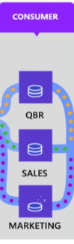

##CONSUMER
Ở giai đoạn consumer, tôi đã dùng phân tích doanh số và hiệu suất bán hàng.

#Doanh số bán hàng theo nền tảng

Một số nền tảng nổi bật vẫn còn nổi tiếng đến sau này được tô màu đỏ

<ipython-input-10-94af41a7a3a6>:13: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
<ipython-input-10-94af41a7a3a6>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


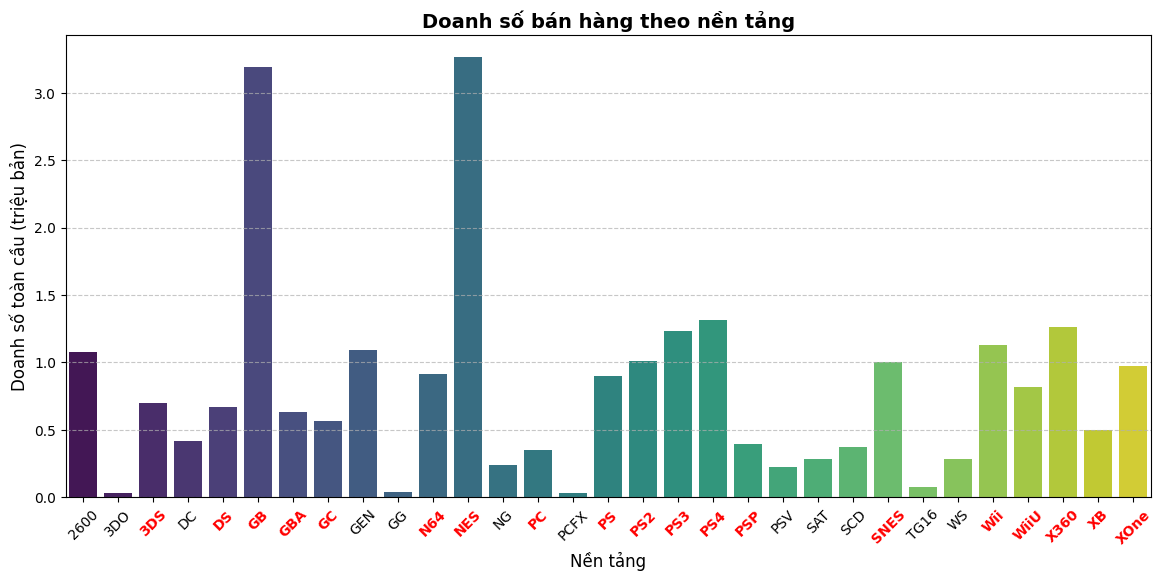

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Danh sách các nền tảng cần làm nổi bật
highlighted_platforms = ["3DS", "DS", "GB", "GBA", "GC", "N64", "NES", "PC",
                         "PS", "PS2", "PS3", "PS4", "PSP", "SNES", "XB",
                         "X360", "XOne", "Wii", "WiiU"]

# Tạo figure
plt.figure(figsize=(14, 6))

# Vẽ biểu đồ với màu sắc
sns.barplot(
    x="Platform", y="Global_Sales", data=olap_data, ci=None,
    palette="viridis"
)

# Làm nổi bật các nhãn quan trọng
plt.xticks(rotation=45, fontsize=10)
for tick in plt.gca().get_xticklabels():
    if tick.get_text() in highlighted_platforms:
        tick.set_fontweight("bold")   # Làm đậm
        tick.set_color("red")         # Đổi màu đỏ

# Tùy chỉnh hiển thị
plt.title("Doanh số bán hàng theo nền tảng", fontsize=14, fontweight="bold")
plt.xlabel("Nền tảng", fontsize=12)
plt.ylabel("Doanh số toàn cầu (triệu bản)", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()


<ipython-input-11-47c8d54ba4da>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_Publishers.index, y=top_Publishers.values, palette="Blues_r")


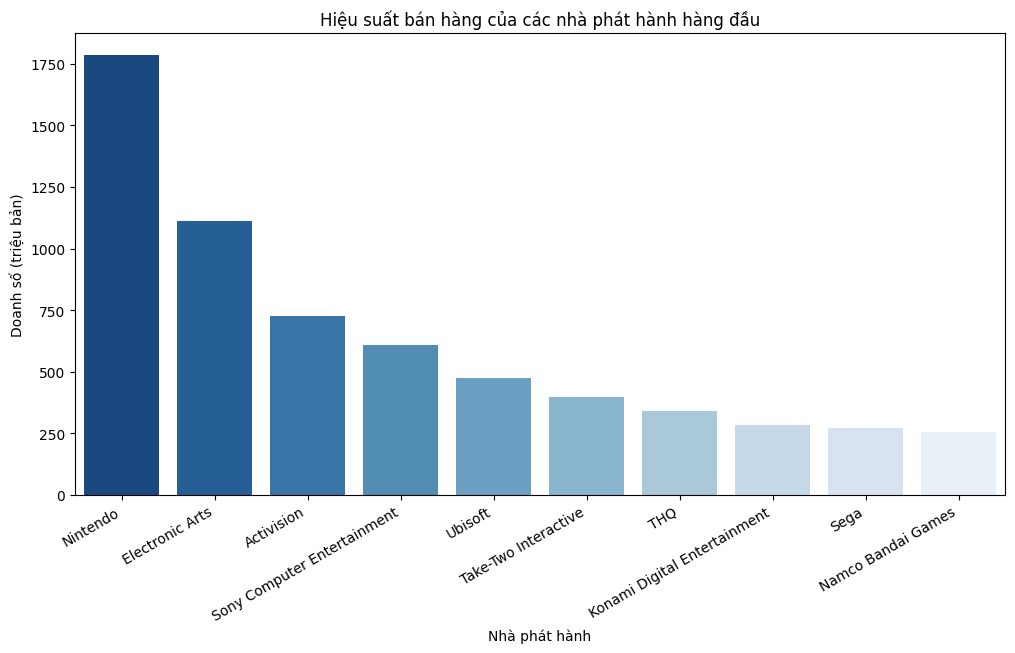

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Tính tổng doanh số toàn cầu của từng nhà phát hành
top_Publishers = df.groupby("Publisher")["Global_Sales"].sum()

# Chọn ra top 10 nhà phát hành có doanh số cao nhất
top_Publishers = top_Publishers.sort_values(ascending=False).head(10)

# Vẽ biểu đồ cột
plt.figure(figsize=(12,6))
sns.barplot(x=top_Publishers.index, y=top_Publishers.values, palette="Blues_r")

# Xoay chữ trục X để dễ đọc
plt.xticks(rotation=30, ha='right')

plt.title("Hiệu suất bán hàng của các nhà phát hành hàng đầu")
plt.xlabel("Nhà phát hành")
plt.ylabel("Doanh số (triệu bản)")
plt.show()


<ipython-input-12-98a8d931c6f9>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_Publishers.index, y=top_Publishers.values, palette="Blues_r")


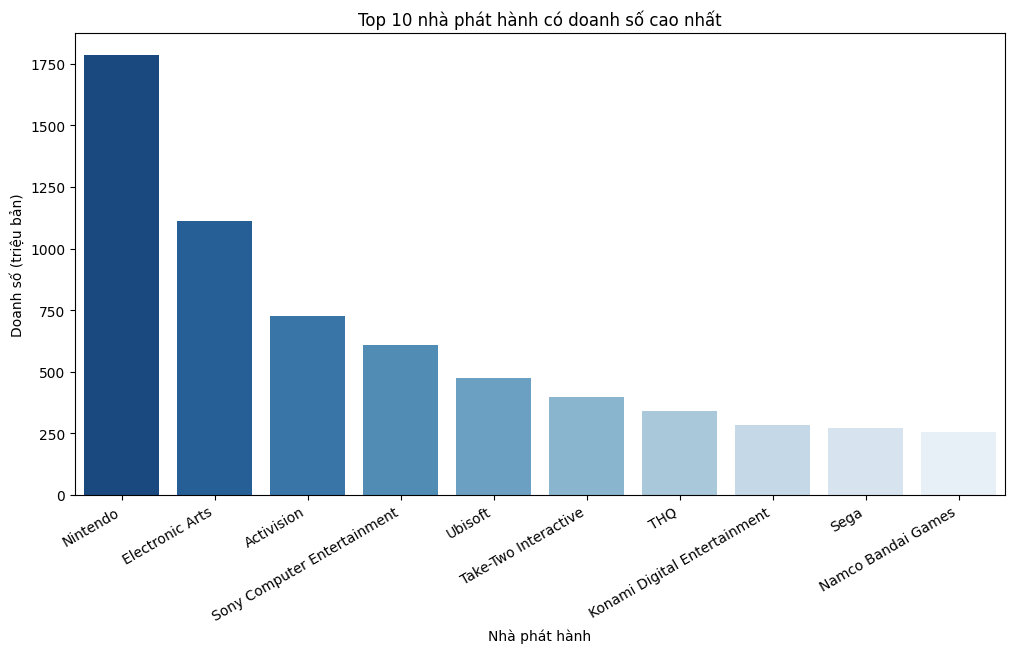

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.barplot(x=top_Publishers.index, y=top_Publishers.values, palette="Blues_r")

plt.xticks(rotation=30, ha='right')  # Xoay chữ cho dễ đọc
plt.ylabel("Doanh số (triệu bản)")
plt.xlabel("Nhà phát hành")
plt.title("Top 10 nhà phát hành có doanh số cao nhất")

plt.show()


#Doanh số theo thể loại qua các năm (top 5)

<ipython-input-13-b460f24edfda>:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df_top, x='Year', y='Global_Sales', hue='Genre', estimator='sum', ci=None, palette="tab10")


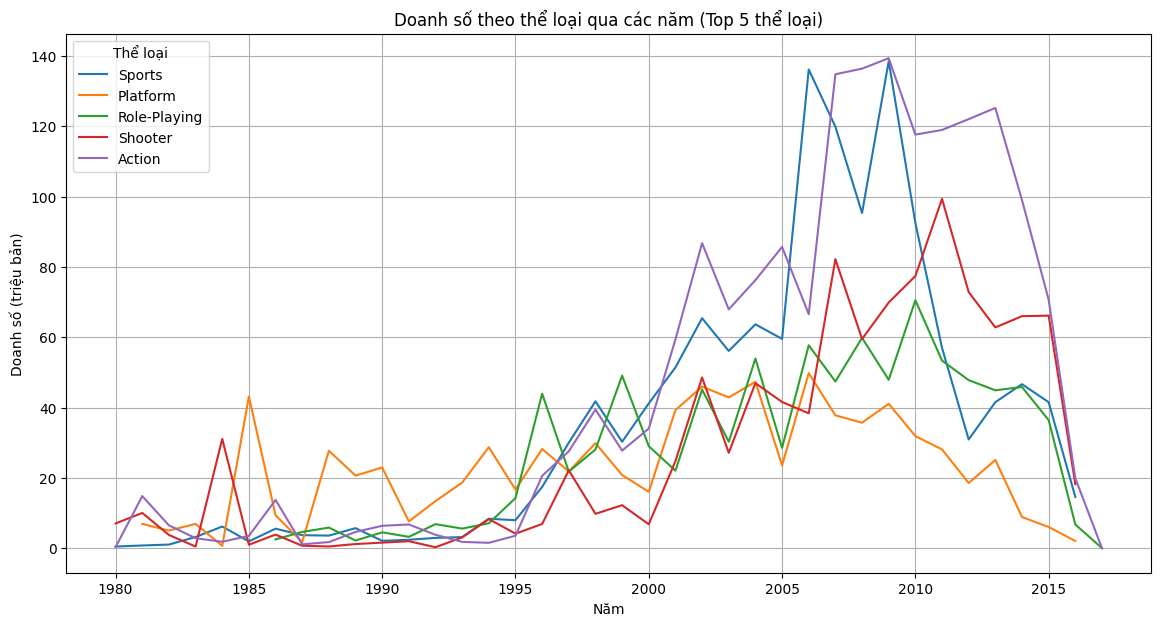

In [ ]:
# Lấy top 5 thể loại có doanh số cao nhất
top_genres = df.groupby('Genre')['Global_Sales'].sum().nlargest(5).index
df_top = df[df['Genre'].isin(top_genres)]

plt.figure(figsize=(14, 7))
sns.lineplot(data=df_top, x='Year', y='Global_Sales', hue='Genre', estimator='sum', ci=None, palette="tab10")

plt.title("Doanh số theo thể loại qua các năm (Top 5 thể loại)")
plt.xlabel("Năm")
plt.ylabel("Doanh số (triệu bản)")
plt.legend(title="Thể loại")
plt.grid(True)

plt.show()

#Doanh số theo thể loại qua các năm

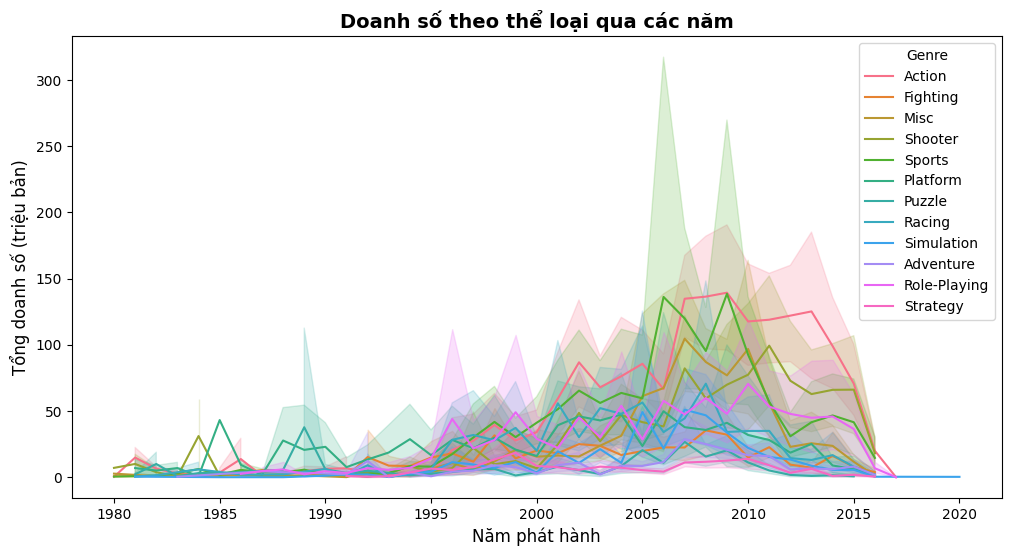

In [ ]:
plt.figure(figsize=(12,6))
sns.lineplot(x="Year", y="Global_Sales", hue="Genre", data=olap_data, estimator=sum)

# Điều chỉnh nhãn trục và tiêu đề
plt.title("Doanh số theo thể loại qua các năm", fontsize=14, fontweight="bold")
plt.xlabel("Năm phát hành", fontsize=12)
plt.ylabel("Tổng doanh số (triệu bản)", fontsize=12)


plt.show()


In ra top 20 nhà phát hành

In [ ]:
print(top_Publishers)
print("----------")
print(df['Publisher'].unique()[:20])  # Xem 20 giá trị đầu tiên trong cột Publisher


Publisher
Nintendo                        1786.56
Electronic Arts                 1110.32
Activision                       727.46
Sony Computer Entertainment      607.50
Ubisoft                          474.72
Take-Two Interactive             399.54
THQ                              340.77
Konami Digital Entertainment     283.64
Sega                             272.99
Namco Bandai Games               254.09
Name: Global_Sales, dtype: float64
----------
['Nintendo' 'Microsoft Game Studios' 'Take-Two Interactive'
 'Sony Computer Entertainment' 'Activision' 'Ubisoft' 'Bethesda Softworks'
 'Electronic Arts' 'Sega' 'SquareSoft' 'Atari' '505 Games' 'Capcom'
 'GT Interactive' 'Konami Digital Entertainment'
 'Sony Computer Entertainment Europe' 'Square Enix' 'LucasArts'
 'Virgin Interactive' 'Warner Bros. Interactive Entertainment']


Doanh số theo thể loại qua các năm (top 5) với chú thích doanh số ở một số điểm

<ipython-input-16-35853c688350>:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  max_sales_by_genre = df_top.groupby("Genre").apply(lambda g: g.loc[g["Global_Sales"].idxmax()])
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.


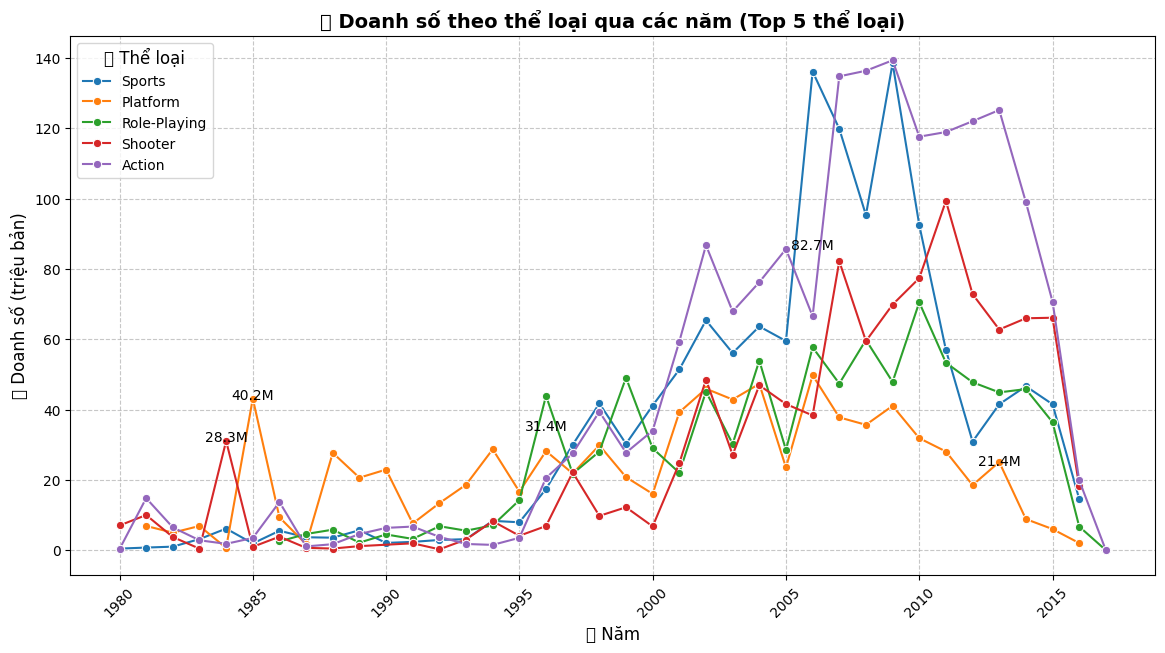

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Lấy top 5 thể loại có doanh số cao nhất
top_genres = df.groupby('Genre')['Global_Sales'].sum().nlargest(5).index
df_top = df[df['Genre'].isin(top_genres)]

# Vẽ biểu đồ
plt.figure(figsize=(14, 7))
sns.lineplot(
    data=df_top, x='Year', y='Global_Sales', hue='Genre',
    estimator='sum', errorbar=None, palette="tab10", marker="o"
)

# Cải thiện đồ thị
plt.title("📊 Doanh số theo thể loại qua các năm (Top 5 thể loại)", fontsize=14, fontweight="bold")
plt.xlabel("📅 Năm", fontsize=12)
plt.ylabel("💰 Doanh số (triệu bản)", fontsize=12)
plt.legend(title="🎮 Thể loại", fontsize=10, title_fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.7)

# Thêm chú thích cho điểm cao nhất của mỗi thể loại
max_sales_by_genre = df_top.groupby("Genre").apply(lambda g: g.loc[g["Global_Sales"].idxmax()])

for _, row in max_sales_by_genre.iterrows():
    plt.annotate(
        f"{row['Global_Sales']:.1f}M",
        (row["Year"], row["Global_Sales"]),
        textcoords="offset points", xytext=(0, 7), ha='center', fontsize=10, color="black"
    )

plt.show()


#So sánh doanh số tổng và top 5 thể loại

Tổng doanh số toàn ngành: 8920.44
Tổng doanh số Top 5 thể loại: 5878.22 (65.90%)
['Sports' 'Platform' 'Role-Playing' 'Shooter' 'Action']
1980.0 2017.0


<ipython-input-17-a39f34becd5f>:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df, x='Year', y='Global_Sales', estimator='sum', ci=None, label="Tổng tất cả thể loại")
<ipython-input-17-a39f34becd5f>:13: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df_top, x='Year', y='Global_Sales', estimator='sum', ci=None, label="Top 5 thể loại")


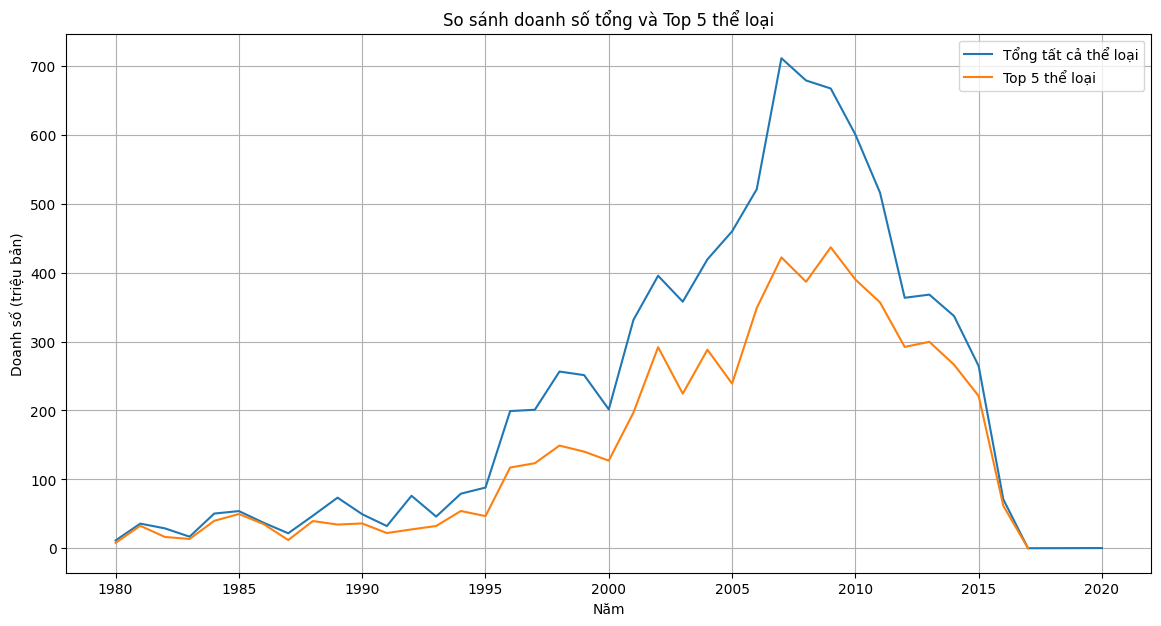

In [ ]:
total_sales = df['Global_Sales'].sum()
top_5_sales = df_top['Global_Sales'].sum()
print(f"Tổng doanh số toàn ngành: {total_sales}")
print(f"Tổng doanh số Top 5 thể loại: {top_5_sales} ({top_5_sales/total_sales:.2%})")
print(df_top['Genre'].unique())  # Xem có đủ 5 thể loại không
print(df_top['Year'].min(), df_top['Year'].max())  # Xem có đủ năm không
plt.figure(figsize=(14, 7))

# Biểu đồ tổng
sns.lineplot(data=df, x='Year', y='Global_Sales', estimator='sum', ci=None, label="Tổng tất cả thể loại")

# Biểu đồ Top 5
sns.lineplot(data=df_top, x='Year', y='Global_Sales', estimator='sum', ci=None, label="Top 5 thể loại")

plt.title("So sánh doanh số tổng và Top 5 thể loại")
plt.xlabel("Năm")
plt.ylabel("Doanh số (triệu bản)")
plt.legend()
plt.grid(True)

plt.show()


In [ ]:
# Xem các giá trị duy nhất của một số cột quan trọng
print(df["Platform"].unique())  # Các nền tảng trò chơi
print(df["Genre"].unique())  # Các thể loại trò chơi
print(df["Publisher"].unique()[:10])  # 10 nhà phát hành đầu tiên


['Wii' 'NES' 'GB' 'DS' 'X360' 'PS3' 'PS2' 'SNES' 'GBA' '3DS' 'PS4' 'N64'
 'PS' 'XB' 'PC' '2600' 'PSP' 'XOne' 'GC' 'WiiU' 'GEN' 'DC' 'PSV' 'SAT'
 'SCD' 'WS' 'NG' 'TG16' '3DO' 'GG' 'PCFX']
['Sports' 'Platform' 'Racing' 'Role-Playing' 'Puzzle' 'Misc' 'Shooter'
 'Simulation' 'Action' 'Fighting' 'Adventure' 'Strategy']
['Nintendo' 'Microsoft Game Studios' 'Take-Two Interactive'
 'Sony Computer Entertainment' 'Activision' 'Ubisoft' 'Bethesda Softworks'
 'Electronic Arts' 'Sega' 'SquareSoft']


#Nhóm các quốc gia lại thành một cột Region để chuẩn bị cho việc tạo Olap cube

In [ ]:
df_melted = df.melt(
    id_vars=["Name", "Genre", "Publisher", "Platform", "Year"],
    value_vars=["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"],
    var_name="Region",
    value_name="Sales"
)


#Tạo Olap cube

In [ ]:
olap_cube = df_melted.pivot_table(
    values="Sales",
    index=["Name", "Genre", "Publisher"],
    columns=["Platform", "Year", "Region"],
    aggfunc="sum",
    fill_value=0
)


#In ra Olap cube

Tổng cộng, OLAP cube có 6 chiều dữ liệu (6D).


📌 3 chiều trong index (hàng dọc):

Name – Tên game.
Genre – Thể loại game.
Publisher – Nhà phát hành.

📌 3 chiều trong columns (hàng ngang):
Platform – Nền tảng chơi game (PS, Xbox, PC, v.v.).
Year – Năm phát hành.
Region – Doanh số của các khu vực bán hàng (NA, EU, JP, Other).

In [ ]:
print(olap_cube.index.names)
print(olap_cube.columns.names)


['Name', 'Genre', 'Publisher']
['Platform', 'Year', 'Region']


#1️⃣ Doanh số bán hàng theo nền tảng và khu vực
#Tạo bảng tổng hợp doanh số bán hàng theo nền tảng (Platform) và khu vực (NA_Sales, EU_Sales, JP_Sales, Other_Sales):


In [ ]:
sales_by_platform_region = df.pivot_table(
    values=["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"],
    index="Platform",
    aggfunc="sum"
)
print(sales_by_platform_region)


          EU_Sales  JP_Sales  NA_Sales  Other_Sales
Platform                                           
2600          5.47      0.00     90.60         0.91
3DO           0.00      0.10      0.00         0.00
3DS          58.52     97.35     78.87        12.63
DC            1.69      8.56      5.43         0.27
DS          194.65    175.57    390.71        60.53
GB           47.82     85.12    114.32         8.20
GBA          75.25     47.33    187.54         7.73
GC           38.71     21.58    133.46         5.18
GEN           5.52      2.67     19.27         0.89
GG            0.00      0.04      0.00         0.00
N64          41.06     34.22    139.02         4.38
NES          21.15     98.65    125.94         5.31
NG            0.00      1.44      0.00         0.00
PC          139.68      0.17     93.28        24.86
PCFX          0.00      0.03      0.00         0.00
PS          213.60    139.82    336.51        40.91
PS2         339.29    139.20    583.84       193.44
PS3         

#2️⃣ Thể loại trò chơi phổ biến theo thời gian và khu vực
#Tạo bảng tổng hợp doanh số bán hàng theo Genre, Year và Region:

In [ ]:
sales_by_genre_year_region = df.pivot_table(
    values=["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"],
    index=["Genre", "Year"],
    aggfunc="sum"
)
print(sales_by_genre_year_region)


                 EU_Sales  JP_Sales  NA_Sales  Other_Sales
Genre    Year                                             
Action   1980.0      0.02      0.00      0.32         0.00
         1981.0      0.81      0.00     13.86         0.12
         1982.0      0.38      0.00      6.07         0.05
         1983.0      0.17      0.00      2.67         0.02
         1984.0      0.19      0.83      0.80         0.03
...                   ...       ...       ...          ...
Strategy 2012.0      0.99      1.11      0.94         0.29
         2013.0      2.47      0.82      2.39         0.64
         2014.0      0.22      0.55      0.16         0.04
         2015.0      0.98      0.15      0.57         0.12
         2016.0      0.32      0.05      0.11         0.04

[389 rows x 4 columns]


#3️⃣ Hiệu suất bán hàng của các nhà phát hành hàng đầu
#Tạo bảng xếp hạng doanh số bán hàng của các nhà phát hành (Publisher):

In [ ]:
top_publishers_sales = df.groupby("Publisher")["Global_Sales"].sum().sort_values(ascending=False)
print(top_publishers_sales.head(10))  # Top 10 nhà phát hành bán chạy nhất


Publisher
Nintendo                        1786.56
Electronic Arts                 1110.32
Activision                       727.46
Sony Computer Entertainment      607.50
Ubisoft                          474.72
Take-Two Interactive             399.54
THQ                              340.77
Konami Digital Entertainment     283.64
Sega                             272.99
Namco Bandai Games               254.09
Name: Global_Sales, dtype: float64


#Visualization sau khi đã xử lí thông quá OLAP

#1️⃣ Doanh số bán hàng theo nền tảng và khu vực

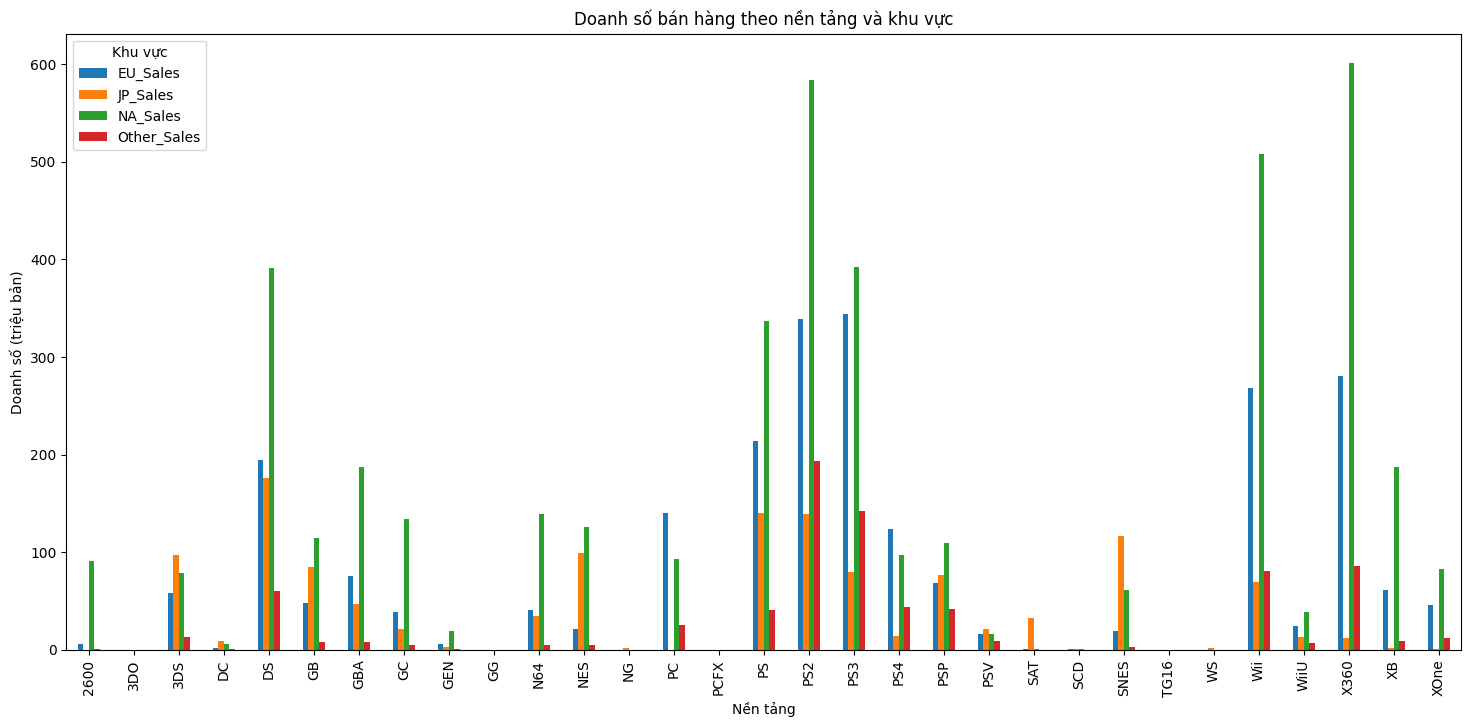

In [ ]:
sales_by_platform_region.plot(kind="bar", stacked=False, figsize=(18,8))
plt.title("Doanh số bán hàng theo nền tảng và khu vực")
plt.xlabel("Nền tảng")
plt.ylabel("Doanh số (triệu bản)")
plt.legend(title="Khu vực")
plt.show()


##Phân tích biểu đồ doanh số bán hàng theo nền tảng và khu vực



1. Nền tảng có doanh số cao nhất

•	PlayStation 2 (PS2) có doanh số vượt trội so với các nền tảng khác, đạt hơn 1200 triệu bản.

•	PlayStation (PS1), PlayStation 3 (PS3) và Nintendo DS (DS) cũng có doanh số rất cao, đứng top đầu.

2. Sự thống trị của các nền tảng PlayStation

•	PS2, PS3, PS1 và PSP đều nằm trong top các nền tảng bán chạy, cho thấy PlayStation chiếm lĩnh thị trường trong thời gian dài.

•	Điều này có thể do sự phổ biến của các tựa game độc quyền mạnh mẽ trên PlayStation như Final Fantasy, Grand Theft Auto, Gran Turismo, Metal Gear Solid,...

3. Nintendo cũng rất mạnh nhưng tập trung hơn vào máy cầm tay
•	Nintendo DS (DS), Wii và Game Boy Advance (GBA) có doanh số cao.

•	Máy chơi game cầm tay của Nintendo như DS, 3DS, GBA có doanh số tốt, đặc biệt tại Nhật Bản.

4. Xbox đứng sau nhưng vẫn cạnh tranh mạnh

•	Xbox 360 (X360) và Xbox One (XOne) có doanh số khá tốt, nhưng vẫn thua PlayStation về tổng doanh số.

•	Thị trường chính của Xbox là Bắc Mỹ (NA_Sales, màu xanh lá), cho thấy Xbox mạnh ở thị trường Mỹ hơn châu Âu và Nhật Bản.

5. Phân bố doanh số theo khu vực

•	Màu xanh lá (NA_Sales) áp đảo, cho thấy Bắc Mỹ là thị trường game lớn nhất.
•	Màu xanh dương (EU_Sales) cũng chiếm tỷ lệ cao, chứng tỏ châu Âu cũng là một thị trường quan trọng.

•	Màu cam (JP_Sales) tập trung chủ yếu ở các nền tảng của Nintendo và Sony, vì Nhật Bản là thị trường mạnh của các hãng này.

•	Màu đỏ (Other_Sales) chiếm phần nhỏ, chứng tỏ các khu vực khác như Úc, Trung Đông, Nam Mỹ có doanh số ít hơn nhiều so với NA, EU và JP.

📌 Kết luận

1.	PlayStation thống trị thị trường console với PS2, PS1, PS3.

2.	Nintendo mạnh về máy cầm tay và có sức ảnh hưởng lớn tại Nhật Bản.

3.	Xbox mạnh ở thị trường Bắc Mỹ nhưng chưa thể vượt qua PlayStation.

4.	Bắc Mỹ và châu Âu là hai thị trường game lớn nhất, trong khi Nhật Bản tập trung chủ yếu vào Nintendo và PlayStation.

📈 Từ biểu đồ này, có thể dự đoán xu hướng thị trường game sẽ tiếp tục xoay quanh PlayStation, Nintendo và Xbox, với Bắc Mỹ và châu Âu vẫn là hai thị trường quan trọng nhất. 🚀


##Đề xuất chiến lược dựa trên doanh số nền tảng và khu vực


1. Tập trung tối ưu hoá nội dung trên nền tảng PlayStation
🎮 Lý do:
PS2, PS1, PS3, và PSP đều thuộc top bán chạy nhất.

PlayStation có tệp người chơi trung thành trải dài nhiều thế hệ.

✅ Chiến lược đề xuất:
Ưu tiên phát hành game trên hệ máy PlayStation trước (hoặc độc quyền thời gian ngắn).

Tận dụng tối đa sức mạnh phần cứng của PS5 và dịch vụ PS Plus.

Phát triển các dòng game cinematic, hành động, phiêu lưu, nhập vai – các thể loại truyền thống mạnh trên PS.

2. Phát triển mạnh dòng game cho máy cầm tay – đặc biệt với Nintendo
📱 Lý do:
DS, 3DS, GBA có doanh số cực cao, nhất là tại Nhật Bản.

Máy cầm tay vẫn là thế mạnh của Nintendo (hiện tại là Nintendo Switch).

✅ Chiến lược đề xuất:
Tập trung phát hành game RPG, phiêu lưu, mô phỏng, casual cho hệ máy Nintendo.

Hợp tác với Nintendo để tạo game độc quyền hoặc chuyển thể phù hợp với lối chơi di động (portable-friendly).

Định vị dòng game gia đình, trẻ em, hoặc người chơi casual – tệp khách hàng chủ đạo của Nintendo.

3. Tận dụng sức mạnh khu vực – Bắc Mỹ và châu Âu là thị trường trọng điểm
🌎 Lý do:
Doanh số tại NA và EU chiếm phần lớn tổng doanh số toàn cầu.

Xbox mạnh ở NA, còn PlayStation và Nintendo có mặt rộng ở cả NA và EU.

✅ Chiến lược đề xuất:
Định vị nội dung theo thị hiếu từng khu vực:

NA: Action, Shooter, Sports – phù hợp với Xbox và PlayStation.

EU: Sports, Racing, Simulation – cần bản địa hoá game theo ngôn ngữ & văn hoá địa phương.

Phát hành theo khung giờ và mùa cao điểm khu vực (hè, lễ cuối năm).

4. Không bỏ quên thị trường Nhật Bản và khu vực "Other"
🗾 Nhật Bản:
Thị trường cực kỳ trung thành với Nintendo và Sony.

Ưa chuộng các game nhập vai, đối kháng, mô phỏng cuộc sống.

✅ Chiến lược:
Đầu tư dịch thuật, lồng tiếng Nhật, giữ nguyên phong cách nghệ thuật phù hợp thị hiếu Á Đông.

Hợp tác với các studio Nhật để phân phối & nội địa hóa.

🌍 Khu vực Other (Nam Mỹ, Úc, Trung Đông, Đông Nam Á):
Dù thị phần nhỏ nhưng đang phát triển nhanh.

✅ Chiến lược:
Phát hành game giá thấp hoặc free-to-play.

Tối ưu cho mobile và PC cấu hình trung bình – dễ tiếp cận với người chơi mới.

🔍 Định hướng dài hạn & xu thế nền tảng
PlayStation tiếp tục thống trị nếu giữ được nội dung độc quyền và hệ sinh thái dịch vụ mạnh.

Nintendo vẫn giữ vai trò “vua máy cầm tay”, nhưng cần sáng tạo thêm phần cứng mới hậu Switch.

Xbox nên mở rộng ngoài Bắc Mỹ, đầu tư vào cloud gaming & Game Pass để tăng tính cạnh tranh.

Các nhà phát hành cần chọn nền tảng phát hành theo khu vực & thể loại phù hợp – không còn “một công thức dùng cho tất cả”.



#Thể loại trò chơi phổ biến theo thời gian

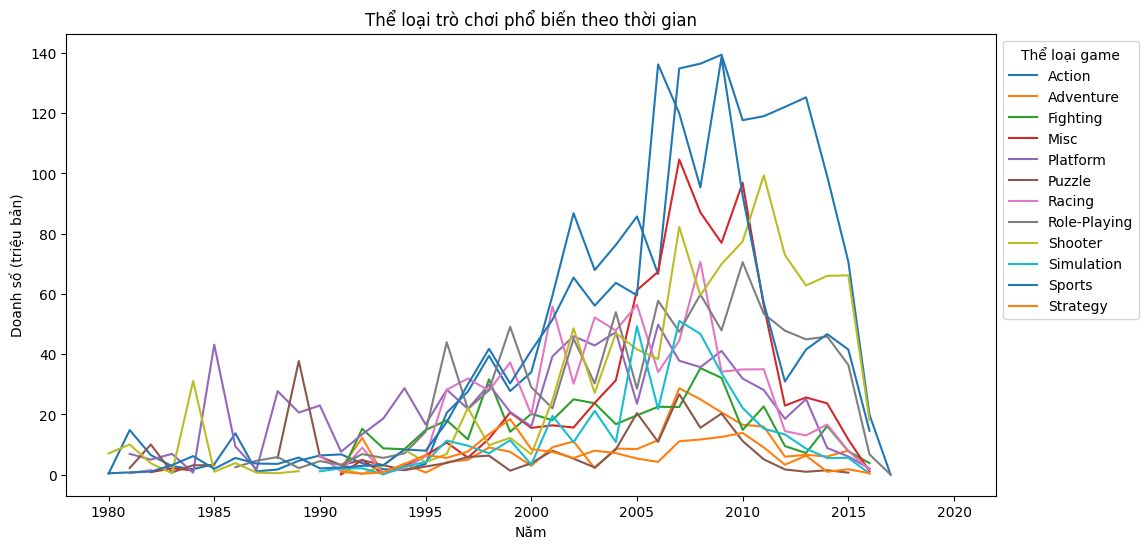

In [ ]:
# Tạo bảng doanh số theo thể loại game và năm
sales_by_genre_year = df.pivot_table(
    values="Global_Sales",
    index="Year",
    columns="Genre",
    aggfunc="sum"
)

# Vẽ biểu đồ đường
sales_by_genre_year.plot(figsize=(12,6))
plt.title("Thể loại trò chơi phổ biến theo thời gian")
plt.xlabel("Năm")
plt.ylabel("Doanh số (triệu bản)")
plt.legend(title="Thể loại game", bbox_to_anchor=(1,1))
plt.show()


#2️⃣ Thể loại trò chơi phổ biến theo thời gian và khu vực

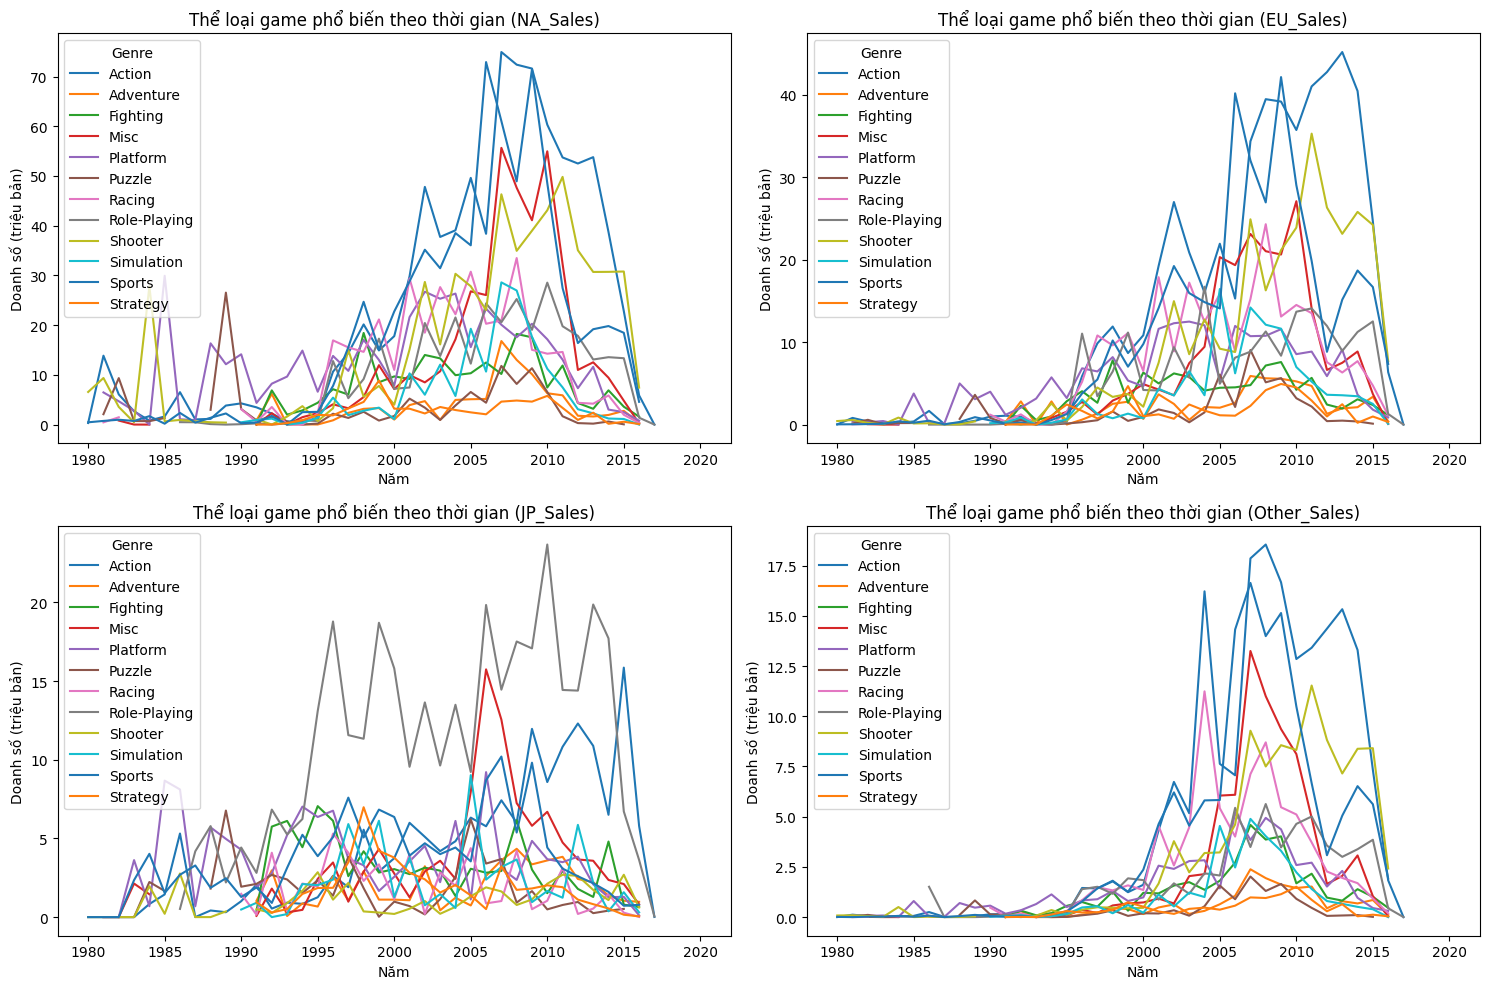

In [ ]:
# Danh sách khu vực cần phân tích
regions = ["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]

# Vẽ 4 biểu đồ đường cho từng khu vực
fig, axes = plt.subplots(2, 2, figsize=(15,10))
axes = axes.flatten()

for i, region in enumerate(regions):
    sales_by_genre_region = df.pivot_table(
        values=region,
        index="Year",
        columns="Genre",
        aggfunc="sum"
    )
    sales_by_genre_region.plot(ax=axes[i])
    axes[i].set_title(f"Thể loại game phổ biến theo thời gian ({region})")
    axes[i].set_xlabel("Năm")
    axes[i].set_ylabel("Doanh số (triệu bản)")

plt.tight_layout()
plt.show()

##Phân tích xu hướng thể loại game phổ biến theo thời gian và khu vực



1. Tổng quan chung

•	Biểu đồ hiển thị xu hướng doanh số của các thể loại game từ khoảng năm 1980 - 2020 tại 4 khu vực:

o	Bắc Mỹ (NA_Sales) - Biểu đồ trên cùng bên trái

o	Châu Âu (EU_Sales) - Biểu đồ trên cùng bên phải

o	Nhật Bản (JP_Sales) - Biểu đồ dưới cùng bên trái

o	Các khu vực khác (Other_Sales) - Biểu đồ dưới cùng bên phải

•	Tất cả khu vực đều đạt đỉnh doanh số vào khoảng 2005 - 2010, sau đó giảm mạnh.

________________________________________

🏆 2. Xu hướng theo khu vực

2.1 Bắc Mỹ (NA_Sales)

•	Thể loại phổ biến nhất:

o	Action (xanh dương) và Shooter (vàng) có doanh số cao nhất, đặc biệt là giai đoạn 2000-2010.

o	Sports (xám) và Racing cũng khá phổ biến.

o	Role-Playing (RPG) không quá nổi bật, cho thấy thị trường Bắc Mỹ ít chuộng game nhập vai hơn.

•	Nhận xét:

o	Bắc Mỹ ưa chuộng game hành động (Action), bắn súng (Shooter) và thể thao (Sports).

o	Thời kỳ hoàng kim của game trong khu vực này rơi vào 2005-2010, sau đó giảm dần.

________________________________________

2.2 Châu Âu (EU_Sales)

•	Xu hướng tương tự Bắc Mỹ nhưng không quá thiên về Shooter.

•	Thể loại phổ biến:

o	Action, Sports, và Shooter vẫn chiếm phần lớn doanh số.

o	Racing cũng khá mạnh, nhưng không nổi bật bằng NA.

•	Nhận xét:

o	Châu Âu có xu hướng gần giống Bắc Mỹ nhưng có sự cân bằng hơn giữa các thể loại.

o	Doanh số đạt đỉnh khoảng 2005-2010, sau đó giảm.

________________________________________

2.3 Nhật Bản (JP_Sales)

•	Khác biệt rõ rệt với Bắc Mỹ và châu Âu:

o	Platform (xám) và Role-Playing (RPG, xanh lá cây nhạt) thống trị doanh số.

o	Fighting (màu đỏ) cũng rất phổ biến, phù hợp với sự phát triển của dòng game đối kháng Nhật Bản như Street Fighter, Tekken.

o	Shooter và Sports lại không quá phổ biến, khác hẳn so với thị trường phương Tây.

•	Nhận xét:

o	Người Nhật thích RPG, Platform và Fighting hơn là Shooter hay Sports.

o	Doanh số game không tăng mạnh như ở NA/EU nhưng vẫn duy trì tốt.

________________________________________

2.4 Các khu vực khác (Other_Sales)

•	Có xu hướng giống Bắc Mỹ và Châu Âu nhưng quy mô nhỏ hơn.

•	Shooter, Action, Sports vẫn thống trị, nhưng tổng doanh số không cao bằng ba khu vực kia.

•	Nhận xét:

o	Các khu vực khác có doanh số thấp hơn, nhưng xu hướng vẫn tương tự phương Tây.

________________________________________

🔥 3. Kết luận quan trọng

1.	Giai đoạn hoàng kim của ngành game toàn cầu là từ 2000 - 2010, sau đó giảm mạnh.

2.	Bắc Mỹ và Châu Âu thích Action, Shooter, Sports.

3.	Nhật Bản ưa chuộng RPG, Platform và Fighting, khác hẳn phương Tây.

4.	Các khu vực khác có xu hướng tương tự phương Tây nhưng doanh số nhỏ hơn.

Phương Tây thích game bắn súng, hành động, thể thao; còn Nhật Bản tập trung vào nhập vai và đối kháng.


## ĐỀ XUẤT PHÁT TRIỂN

🎯 Đề xuất chiến lược phát hành game theo khu vực
1. Tối ưu hóa phát hành theo khu vực địa lý
📍 Bắc Mỹ & Châu Âu
Tập trung phát triển các game thuộc thể loại:

🔫 Shooter (bắn súng)

🎮 Action (hành động)

⚽ Sports (thể thao)

🏎️ Racing (đua xe)

Chiến lược:

Ưu tiên phát hành các game có yếu tố chiến đấu tốc độ cao, đồ họa mạnh, và cơ chế chơi linh hoạt.

Tăng cường các giải đấu eSports hoặc các sự kiện cộng đồng để duy trì sự gắn kết với game hành động và thể thao.

Tập trung vào console và PC là chủ yếu, do nhóm người chơi hardcore chiếm đa số ở hai thị trường này.

📍 Nhật Bản
Tập trung phát triển các game thuộc thể loại:

🧙‍♂️ RPG (nhập vai)

🕹️ Platform (đi cảnh)

🥋 Fighting (đối kháng)

Chiến lược:

Ưu tiên phát hành các game có chiều sâu cốt truyện, phát triển nhân vật, yếu tố văn hóa Á Đông hoặc anime.

Hợp tác với các hãng truyện tranh/manga để phát triển game theo IP nổi tiếng (VD: Naruto, Dragon Ball…).

Ưu tiên hệ máy cầm tay, mobile, hoặc Nintendo Switch – phù hợp với văn hóa chơi game nhanh, gọn và tiện lợi.

📍 Các khu vực khác (Other_Sales)
Tập trung vào:

Các game phổ biến toàn cầu: Action, Shooter, Sports nhưng nhẹ hơn về cấu hình.

Chiến lược:

Ưu tiên phát hành game đa nền tảng (PC, console, mobile).

Cân nhắc phát hành các phiên bản rút gọn hoặc “free-to-play” để dễ tiếp cận hơn với người dùng ở các thị trường mới nổi.

2. Tận dụng thời điểm vàng & xu hướng giảm
Thị trường toàn cầu đạt đỉnh từ 2005–2010, nhưng đã chững lại => nhà phát hành cần:

Tìm cách đổi mới gameplay hoặc tích hợp yếu tố mới (AR/VR, AI, multiplayer toàn cầu).

Tái phát hành hoặc làm lại các game kinh điển theo xu hướng hoài cổ (nostalgia).

Tập trung vào phát triển dịch vụ đi kèm: Season Pass, Item Shop, Events để duy trì doanh thu lâu dài.

3. Phát triển theo sở thích văn hóa địa phương
Cần bản địa hóa nội dung, không chỉ ngôn ngữ mà còn về thẩm mỹ, nhân vật, cốt truyện phù hợp từng thị trường.

VD: Game ra mắt ở Nhật nên có yếu tố anime, thần thoại Nhật hoặc bối cảnh Á Đông.

Game ở phương Tây nên có nội dung gần với chiến tranh, zombie, thể thao hiện đại, v.v.

4. Dự đoán tương lai & gợi ý mở rộng
Mobile Game vẫn sẽ phát triển mạnh, đặc biệt ở các khu vực “Other” và Nhật.

Cross-platform & Cloud Gaming là xu thế để phá vỡ giới hạn nền tảng.

Game-as-a-Service (GaaS) giúp giữ chân người chơi và tạo doanh thu liên tục.

#3️⃣ Hiệu suất bán hàng của các nhà phát hành hàng đầu

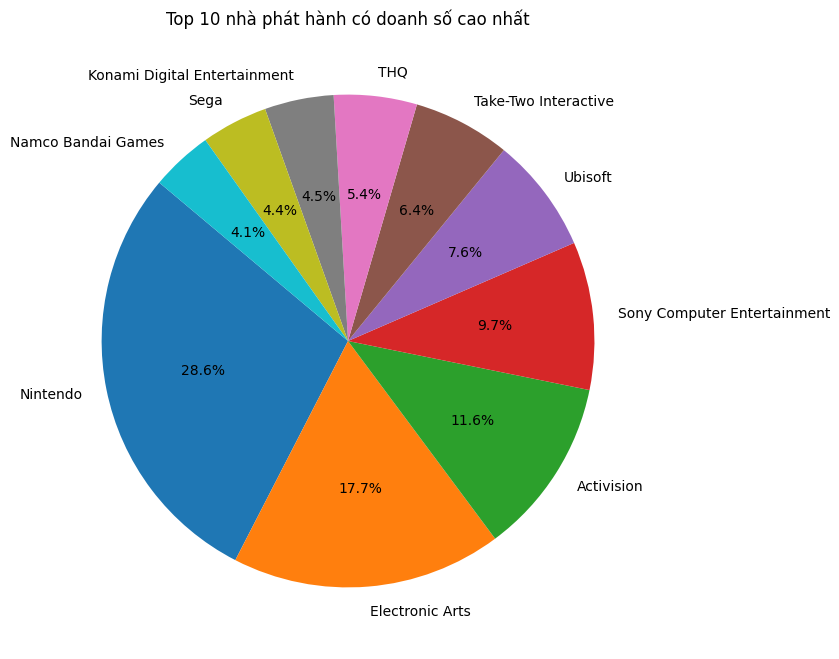

In [ ]:
# Lấy top 10 nhà phát hành có doanh số cao nhất
top_publishers_sales = df.groupby("Publisher")["Global_Sales"].sum().sort_values(ascending=False).head(10)

# Vẽ biểu đồ tròn
plt.figure(figsize=(8,8))
plt.pie(top_publishers_sales, labels=top_publishers_sales.index, autopct="%1.1f%%", startangle=140)
plt.title("Top 10 nhà phát hành có doanh số cao nhất")
plt.show()


##Phân tích biểu đồ Top 10 nhà phát hành có doanh số cao nhất



1.	Nintendo thống trị thị trường:

o	Nintendo chiếm 28.6% tổng doanh số trong top 10, khẳng định vị thế số 1 trong ngành game.

o	Điều này có thể đến từ việc Nintendo có nhiều dòng game độc quyền và nền tảng console phổ biến (Mario, Zelda, Pokémon).

2.	Electronic Arts (EA) đứng thứ hai:

o	EA chiếm 17.7%, chủ yếu nhờ các tựa game thể thao như FIFA, Madden NFL và các series đình đám như The Sims, Battlefield.
3.	Các công ty lớn khác:

o	Activision (11.6%) nổi bật với Call of Duty, Guitar Hero.

o	Sony Computer Entertainment (9.7%) phát triển nhiều tựa game độc quyền cho PlayStation như God of War, The Last of Us.

o	Ubisoft (7.6%) mạnh về game thế giới mở như Assassin’s Creed, Far Cry.

4.	Nhóm công ty có thị phần thấp hơn (dưới 7%):

o	Take-Two Interactive (6.4%) – chủ yếu nhờ Grand Theft Auto, Red Dead Redemption.

o	THQ (5.4%) – có nhiều game thành công trước khi phá sản.

o	Sega, Konami, Namco Bandai Games – đều là những tên tuổi lớn nhưng không còn thống trị như trước.

Nhận xét tổng thể:

•	Nintendo và EA chiếm gần một nửa tổng doanh số trong danh sách, cho thấy sự áp đảo của hai công ty này.

•	Sony và Ubisoft có thị phần đáng kể nhưng không bằng Nintendo hay EA.

•	Một số công ty từng lớn mạnh nhưng đã suy yếu, như THQ (đã phá sản) hoặc Sega (không còn phát triển console).

•	Sự phân hóa trong ngành game: một số công ty tập trung vào game console, số khác mạnh về PC hoặc game online.


## ĐỀ XUẤT PHÁT TRIỂN

Đề xuất chiến lược cho các nhà phát hành game
1. Tận dụng vị thế hiện tại & gia cố thương hiệu
🏆 Nintendo – Thế lực số 1
Chiến lược đề xuất:

Tiếp tục duy trì hệ sinh thái độc quyền với các IP mạnh như Mario, Zelda, Pokémon.

Mở rộng khả năng đa nền tảng, khai thác mobile và các thiết bị chơi game đeo tay để thu hút người chơi mới.

Đầu tư vào công nghệ thực tế tăng cường (AR) hoặc trải nghiệm gia đình (family-friendly) – đúng sở trường của Nintendo.

Cơ hội:

Mở rộng thị phần ở các khu vực "Other Sales" nơi console Nintendo được ưa chuộng (VD: châu Á ngoài Nhật, Nam Mỹ).

🥈 Electronic Arts (EA) – “Vua” game thể thao
Chiến lược đề xuất:

Đầu tư mạnh vào eSports chuyên nghiệp (FIFA, Madden, NHL).

Mở rộng các tựa game thể thao sang nền tảng mobile và cloud gaming.

Làm mới và “live-service” hóa các thương hiệu cũ như Battlefield, The Sims.

Cơ hội:

Kết nối với các giải thể thao thực tế (giải bóng đá, NFL, UFC...) để đồng phát hành game theo mùa giải.

2. Định vị lại thương hiệu với sức bật riêng
🔥 Activision – Shooter & âm nhạc
Đề xuất:

Duy trì Call of Duty bằng nội dung định kỳ, Battle Pass và multiplayer toàn cầu.

Hồi sinh các series như Guitar Hero theo xu hướng "retro" hoặc tích hợp nền tảng âm nhạc số.

Cơ hội:

Phát triển mạnh ở Bắc Mỹ và Châu Âu – nơi yêu thích game hành động và âm nhạc.

🎮 Sony Computer Entertainment – Ông lớn hệ máy
Đề xuất:

Tăng tốc phát hành game độc quyền chất lượng cao trên PS5, kết hợp dịch vụ PS Plus để giữ chân người dùng.

Tăng cường chuyển thể các game độc quyền thành phim hoặc series (như The Last of Us).

Cơ hội:

Dẫn đầu thị trường game console ở phương Tây.

🌍 Ubisoft – Game thế giới mở
Đề xuất:

Tái định vị lại thương hiệu Assassin’s Creed với mô hình dài hơi, đa thế giới, nhiều quốc gia.

Tăng cường yếu tố nhập vai (RPG) để thu hút người chơi châu Á.

Cơ hội:

Xâm nhập các thị trường đang phát triển bằng mô hình free-to-play hoặc game mobile chiến thuật.

3. Chiến lược phục hồi hoặc chuyển hướng phát triển
🧩 Take-Two Interactive
Đề xuất:

Chuẩn bị chiến dịch phát hành lớn cho GTA VI – "gà đẻ trứng vàng" của hãng.

Phát triển thêm nhánh game chiến thuật, mô phỏng hoặc nhập vai bên cạnh game bạo lực.

Cơ hội:

Mở rộng GTA Online để tạo doanh thu định kỳ như dịch vụ.

⚠️ THQ, Sega, Konami, Namco Bandai
Chiến lược tái định vị:

Chuyển hướng sang niche market (thị trường ngách): retro, remake, indie game, visual novel, hoặc VR/AR.

Tận dụng thương hiệu cũ để tái phát hành theo hướng hoài cổ (nostalgia).

Cơ hội:

Lấy lại thị phần tại Nhật Bản, nơi game đi cảnh và đối kháng vẫn có tệp người chơi trung thành.

##DELIVERY

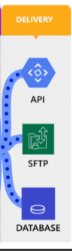

Bước Delivery trong quy trình ETL nhằm mục đích chuyển giao hoặc lưu trữ dữ liệu đã được xử lý, giúp dữ liệu có thể được chia sẻ, lưu trữ hoặc sử dụng trong các ứng dụng khác.

Công việc đã thực hiện:
Để hoàn thành bước Delivery, tôi đã xuất dữ liệu đã xử lý vào một tệp CSV bằng phương thức to_csv() của Pandas.

In [ ]:
# Xuất dữ liệu đã xử lý vào tệp CSV
olap_data.to_csv('olap_sales_report.csv', index=False)


Dữ liệu đã được nhóm và tổng hợp (OLAP) trong DataFrame olap_data được xuất thành tệp CSV có tên olap_sales_report.csv.

Tham số index=False đảm bảo rằng chỉ mục (index) của DataFrame không được ghi vào tệp, giúp tệp trở nên sạch sẽ và dễ sử dụng cho các mục đích khác.

Tệp CSV chứa báo cáo doanh thu của các trò chơi điện tử theo nền tảng, thể loại, nhà phát hành, và khu vực bán hàng đã được tạo và lưu trữ thành công. Tệp này có thể được chia sẻ hoặc sử dụng trong các hệ thống khác để phân tích hoặc báo cáo.